# Test 2: Quadruple-Well KSWGD and DMPS

This notebook keeps the original quadruple-well data generation, parameter values, DMPS update, and KSWGD update. Shared Python modules hold the repeated implementation details.

In [1]:
from dataclasses import replace
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
from IPython.display import display

from plotting_utils import setup_plot_style, ensure_dir
setup_plot_style(scale=1.5)
TEST2_SEED = 73
np.random.seed(TEST2_SEED)
random.seed(TEST2_SEED)
torch.manual_seed(TEST2_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(TEST2_SEED)

from systems import (
    QuadrupleWellConfig, FourWellPotential,
    generate_quadruple_langevin_trajectory,
    init_quadruple_particles_uniform_outside,
)
from dmps import fit_diffusion_map_dmps_2d, run_diffusion_map_dmps_2d
from kswgd import train_sdmd_solver, sdmd_kernel_spectrum_2d, run_kernel_spectrum_transport_2d
from baseline import (
    mmd_rbf, sliced_wasserstein, particle_well_coverage,
    compute_kl_divergence_kde,
)
from experiment_plots import (
    plot_quad_pair_snapshots, plot_quad_heatmaps, plot_quad_movement_rate,
    plot_quad_well_density_evolution, plot_quad_kl_divergence,
)

cfg = replace(
    QuadrupleWellConfig(),
    n_target=10000, n_particles=3000, n_iter=3000,
    step_size=0.05, dt=0.01, substeps=10, burnin=1000, seed=TEST2_SEED,
)
potential = FourWellPotential(cfg.temperature, a=cfg.a, b=cfg.b, coupling=cfg.coupling)
WELL_CENTERS = FourWellPotential.centers
WELL_RADIUS = 0.4
ALPHA_REPULSIVE = 0.5
DM_SPECTRAL_MODES = 1000
RECORD_INTERVAL = 100
SNAPSHOT_STEPS = [0, 1000, 3000]
WELL_DENSITY_STEPS = [0, 100, 300, 500, 1000, 1500, 2000, 2500, 3000]
KL_STEPS = list(range(0, cfg.n_iter + 1, 100))
ALL_SNAPSHOT_STEPS = sorted(set(SNAPSHOT_STEPS + WELL_DENSITY_STEPS + KL_STEPS))
ensure_dir('figures/quadruple_well')
print(cfg)
print(f'alpha_repulsive={ALPHA_REPULSIVE}, well_radius={WELL_RADIUS}, DM spectral modes={DM_SPECTRAL_MODES}')

QuadrupleWellConfig(n_target=10000, n_particles=3000, n_iter=3000, step_size=0.05, dt=0.01, burnin=1000, substeps=10, temperature=1.0, a=1.0, b=1.0, coupling=0.0, seed=73, bounds=(-2.0, 2.0))
alpha_repulsive=0.5, well_radius=0.4, DM spectral modes=1000


In [2]:
from types import SimpleNamespace
from pathlib import Path

CACHE_PATH = Path(f'data/test_2_quadruple_well_core_cache_seed_{cfg.seed}.npz')

def _load_core_cache(path):
    with np.load(path, allow_pickle=False) as cache:
        X_tar = cache['X_tar'].copy()
        X_next = cache['X_next'].copy()
        X_init = cache['X_init'].copy()
        cache_steps = [int(step) for step in cache['cache_steps']]
        dmps = SimpleNamespace(
            final=cache['dmps_snapshots'][-1].copy(),
            snapshots={step: cache['dmps_snapshots'][idx].copy() for idx, step in enumerate(cache_steps)},
            metrics={
                'steps': cache['dmps_metric_steps'].copy(),
                'well_coverage': cache['dmps_well_coverage'].copy(),
                'avg_potential': cache['dmps_avg_potential'].copy(),
                'movement_rate': cache['dmps_movement_rate'].copy(),
            },
        )
        kswgd = SimpleNamespace(
            final=cache['kswgd_snapshots'][-1].copy(),
            snapshots={step: cache['kswgd_snapshots'][idx].copy() for idx, step in enumerate(cache_steps)},
            metrics={
                'steps': cache['kswgd_metric_steps'].copy(),
                'well_coverage': cache['kswgd_well_coverage'].copy(),
                'avg_potential': cache['kswgd_avg_potential'].copy(),
                'movement_rate': cache['kswgd_movement_rate'].copy(),
            },
        )
    return X_tar, X_next, X_init, dmps, kswgd

try:
    X_tar, X_next, X_init, dmps, kswgd = _load_core_cache(CACHE_PATH)
except (FileNotFoundError, OSError, KeyError, ValueError) as cache_error:
    start = time.time()
    print(f'Could not load cache from {CACHE_PATH}: {cache_error}. Regenerating DMPS/KSWGD core results...')
    X_tar, X_next, trajectory = generate_quadruple_langevin_trajectory(cfg, potential, return_trajectory=True)
    X_init = init_quadruple_particles_uniform_outside(cfg, radius=WELL_RADIUS, seed=cfg.seed)
    print(f'X_tar shape: {X_tar.shape}; X_next shape: {X_next.shape}; trajectory shape: {trajectory.shape}')
    print(f'Initial outside-well particles: {X_init.shape[0]} from {cfg.n_particles} uniform candidates')

    print('\nFitting the original DMPS diffusion-map spectrum...')
    dmps_model = fit_diffusion_map_dmps_2d(X_tar, dt=cfg.dt, max_modes=DM_SPECTRAL_MODES)
    print(f'DMPS epsilon={dmps_model.epsilon:.6f}; modes available={len(dmps_model.eigenvalues)}')

    print('\nRunning DMPS with the original repulsive-force update...')
    dmps = run_diffusion_map_dmps_2d(
        dmps_model, X_init, n_iter=cfg.n_iter, step_size=cfg.step_size,
        alpha_repulsive=ALPHA_REPULSIVE, snapshot_steps=ALL_SNAPSHOT_STEPS,
        record_interval=RECORD_INTERVAL, potential=potential, well_centers=WELL_CENTERS,
        well_radius=WELL_RADIUS, progress=True,
    )

    print('\nTraining the original neural dictionary spectrum for KSWGD...')
    solver = train_sdmd_solver(
        X_tar, X_next, input_size=2, layer_sizes=[20], n_psi_train=17,
        target_dim=2, delta_t=cfg.dt, reg=0.1, epochs=6, batch_size=256,
        lr=1e-5, fnn_batch_size=32,
        checkpoint_file='checkpoints/quadruple_well_2d_example_ckpt001.torch',
        fnn_checkpoint_file='checkpoints/example_fnn001.torch',
        a_b_file='checkpoints/a_b_example_quadruple_well.jbl',
    )
    kswgd_model = sdmd_kernel_spectrum_2d(solver, X_tar, base_kernel=dmps_model, dt=cfg.dt, method='KSWGD')
    print(f'KSWGD modes available={len(kswgd_model.eigenvalues)}')

    print('\nRunning KSWGD with the original target-kernel SDMD update...')
    kswgd = run_kernel_spectrum_transport_2d(
        kswgd_model, X_init, n_iter=cfg.n_iter, step_size=cfg.step_size,
        alpha_repulsive=ALPHA_REPULSIVE, snapshot_steps=ALL_SNAPSHOT_STEPS,
        record_interval=RECORD_INTERVAL, potential=potential, well_centers=WELL_CENTERS,
        well_radius=WELL_RADIUS, progress=True,
    )

    for name, res in {'DMPS': dmps, 'KSWGD': kswgd}.items():
        print(
            f"{name}: MMD={mmd_rbf(X_tar, res.final):.4f}, "
            f"SW={sliced_wasserstein(X_tar, res.final, seed=cfg.seed):.4f}, "
            f"particle well coverage={particle_well_coverage(res.final, WELL_CENTERS, WELL_RADIUS):.1f}%"
        )

    cache_steps = list(ALL_SNAPSHOT_STEPS)
    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        CACHE_PATH,
        X_tar=X_tar,
        X_next=X_next,
        X_init=X_init,
        cache_steps=np.asarray(cache_steps, dtype=np.int64),
        dmps_snapshots=np.stack([dmps.snapshots[step] for step in cache_steps]),
        kswgd_snapshots=np.stack([kswgd.snapshots[step] for step in cache_steps]),
        dmps_metric_steps=dmps.metrics['steps'],
        dmps_well_coverage=dmps.metrics['well_coverage'],
        dmps_avg_potential=dmps.metrics['avg_potential'],
        dmps_movement_rate=dmps.metrics['movement_rate'],
        kswgd_metric_steps=kswgd.metrics['steps'],
        kswgd_well_coverage=kswgd.metrics['well_coverage'],
        kswgd_avg_potential=kswgd.metrics['avg_potential'],
        kswgd_movement_rate=kswgd.metrics['movement_rate'],
    )
    print(f'Saved regenerated DMPS/KSWGD core results to {CACHE_PATH}')
    print(f'Test 2 computation finished in {(time.time() - start) / 60:.2f} min')
else:
    print(f'Loaded cached DMPS/KSWGD core results from {CACHE_PATH}')


Could not load cache from data\test_2_quadruple_well_core_cache_seed_73.npz: [Errno 2] No such file or directory: 'data\\test_2_quadruple_well_core_cache_seed_73.npz'. Regenerating DMPS/KSWGD core results...
X_tar shape: (9999, 2); X_next shape: (9999, 2); trajectory shape: (10000, 2)
Initial outside-well particles: 2627 from 3000 uniform candidates

Fitting the original DMPS diffusion-map spectrum...
DMPS epsilon=0.020000; modes available=1000

Running DMPS with the original repulsive-force update...
DMPS: step 500/3000, mean step norm=1.279e-04
DMPS: step 1000/3000, mean step norm=6.107e-05
DMPS: step 1500/3000, mean step norm=4.321e-05
DMPS: step 2000/3000, mean step norm=3.710e-05
DMPS: step 2500/3000, mean step norm=3.326e-05
DMPS: step 3000/3000, mean step norm=3.193e-05

Training the original neural dictionary spectrum for KSWGD...
SDMD training data: train=(6999, 2), valid=(2999, 2), device=cuda
Epoch: 1 	Training Loss: 0.323429 	Validation Loss: 0.038270
Saving model, validati

Processing batches:   0%|          | 0/110 [00:00<?, ?batch/s]c:\Users\xyc93\AppData\Local\anaconda3\envs\myvenvtorch\lib\site-packages\torch\_functorch\deprecated.py:61: UserWarning: We've integrated functorch into PyTorch. As the final step of the integration, functorch.vmap is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use torch.vmap instead; see the PyTorch 2.0 release notes and/or the torch.func migration guide for more details https://pytorch.org/docs/master/func.migrating.html
  warn_deprecated('vmap', 'torch.vmap')
Processing batches: 100%|██████████| 110/110 [00:00<00:00, 143.34batch/s]


saving FNN a and b to:  checkpoints\a_b_example_quadruple_well.jbl
Outer Epoch 1/6


Processing batches: 100%|██████████| 110/110 [00:00<00:00, 213.27batch/s]


Epoch: 1 	Training Loss: 0.002797 val loss: 0.002854
Saving model, val loss improved from 1000000000000000.000000 to 0.002854
Epoch: 2 	Training Loss: 0.002786 val loss: 0.002844
Saving model, val loss improved from 0.002854 to 0.002844
EarlyStopping counter: 1 out of 7
Epoch 1 time: 0.83 seconds
Outer Epoch 2/6


...

Epoch: 1 	Training Loss: 0.002736 val loss: 0.002792
Saving model, val loss improved from 0.002802 to 0.002792
Epoch: 2 	Training Loss: 0.002726 val loss: 0.002782
Saving model, val loss improved from 0.002792 to 0.002782
EarlyStopping counter: 1 out of 7
Epoch 4 time: 0.83 seconds
Outer Epoch 5/6


Processing batches: 100%|██████████| 110/110 [00:00<00:00, 197.64batch/s]


Epoch: 1 	Training Loss: 0.002716 val loss: 0.002772
Saving model, val loss improved from 0.002782 to 0.002772
Epoch: 2 	Training Loss: 0.002707 val loss: 0.002763
Saving model, val loss improved from 0.002772 to 0.002763
EarlyStopping counter: 1 out of 7
Epoch 5 time: 0.88 seconds
Outer Epoch 6/6


Processing batches: 100%|██████████| 110/110 [00:00<00:00, 214.45batch/s]


Epoch: 1 	Training Loss: 0.002698 val loss: 0.002753
Saving model, val loss improved from 0.002763 to 0.002753
Epoch: 2 	Training Loss: 0.002689 val loss: 0.002744
Saving model, val loss improved from 0.002753 to 0.002744
EarlyStopping counter: 1 out of 7
Epoch 6 time: 0.83 seconds
KSWGD modes available=20

Running KSWGD with the original target-kernel SDMD update...
KSWGD: step 500/3000, mean step norm=2.145e-04
KSWGD: step 1000/3000, mean step norm=1.098e-04
KSWGD: step 1500/3000, mean step norm=8.800e-05
KSWGD: step 2000/3000, mean step norm=7.734e-05
KSWGD: step 2500/3000, mean step norm=7.549e-05
KSWGD: step 3000/3000, mean step norm=7.395e-05
DMPS: MMD=0.1374, SW=0.2448, particle well coverage=15.9%
KSWGD: MMD=0.1044, SW=0.1293, particle well coverage=54.5%
Saved regenerated DMPS/KSWGD core results to data\test_2_quadruple_well_core_cache_seed_73.npz
Test 2 computation finished in 12.97 min


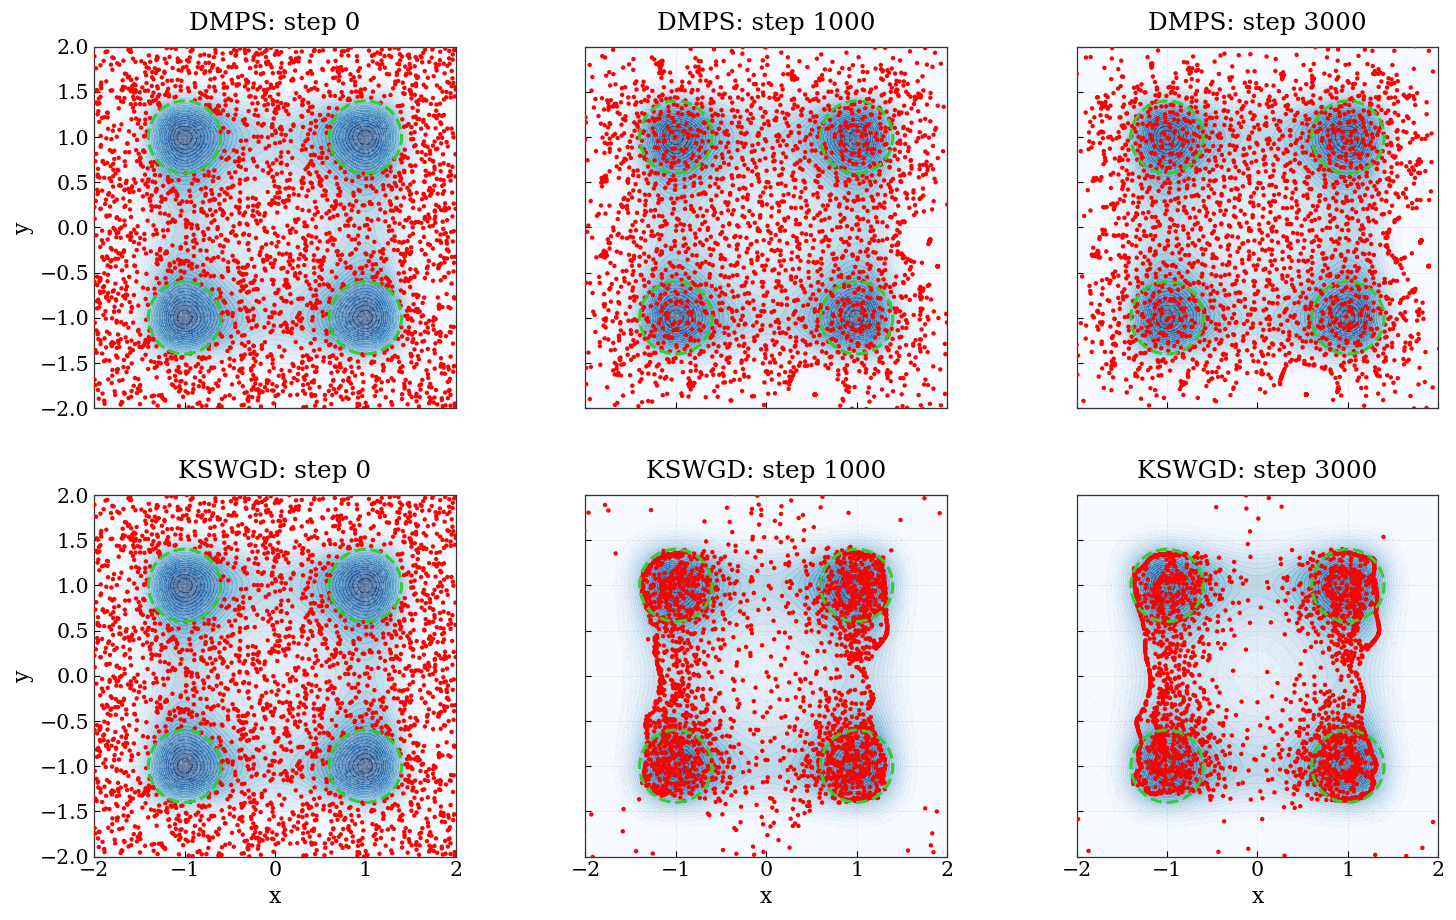

Caption: Quadruple-well particle positions at initialization, 1000 iterations, and 3000 iterations for DMPS and KSWGD.
Saved: figures\quadruple_well\test_2_quadruple_well_particle_snapshots.png and figures\quadruple_well\test_2_quadruple_well_particle_snapshots.pdf


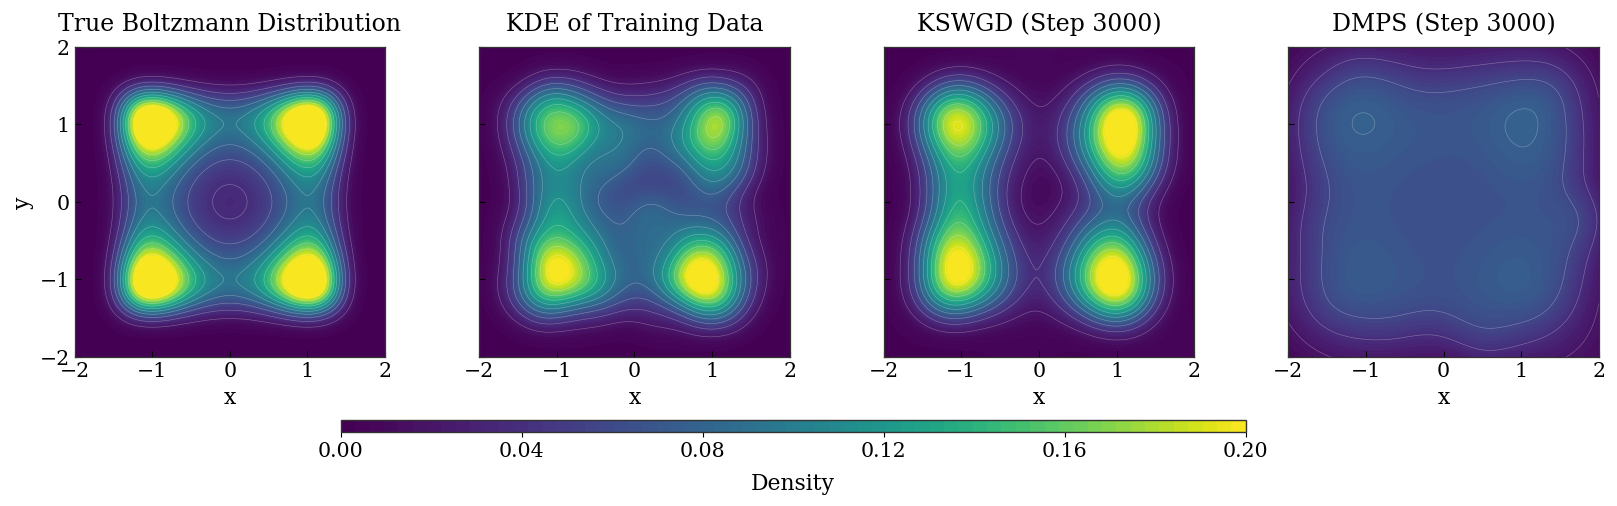

Caption: Density heatmap comparison for the quadruple-well Boltzmann law, training trajectory, KSWGD final particles, and DMPS final particles.
Saved: figures\quadruple_well\test_2_quadruple_well_density_heatmaps.png and figures\quadruple_well\test_2_quadruple_well_density_heatmaps.pdf


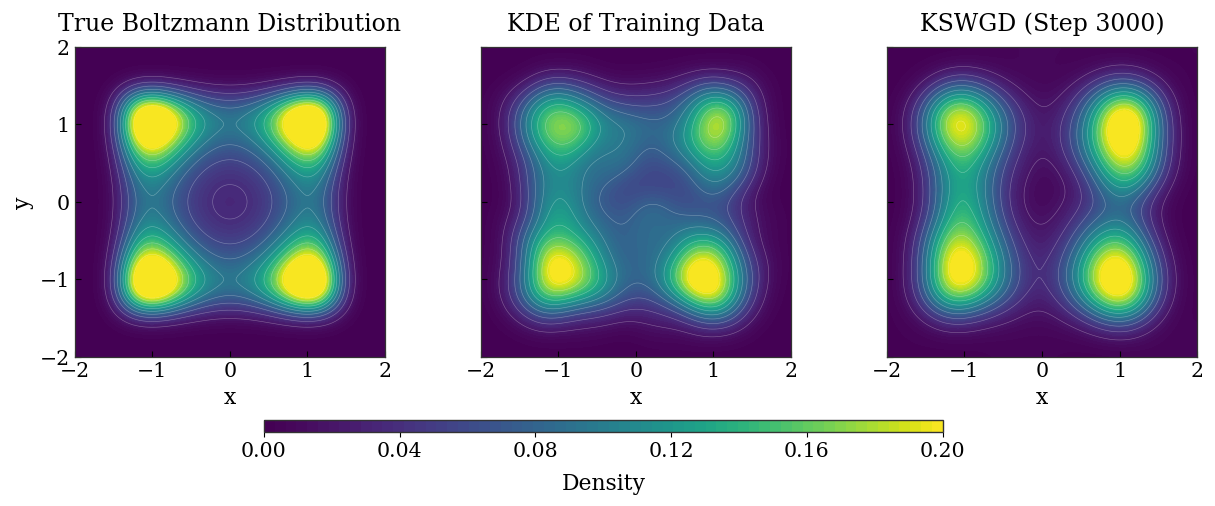

Caption: Three-panel density heatmap comparison for the quadruple-well Boltzmann law, training trajectory, and final KSWGD particles.
Saved: figures\quadruple_well\test_2_quadruple_well_density_heatmaps_1x3.png and figures\quadruple_well\test_2_quadruple_well_density_heatmaps_1x3.pdf


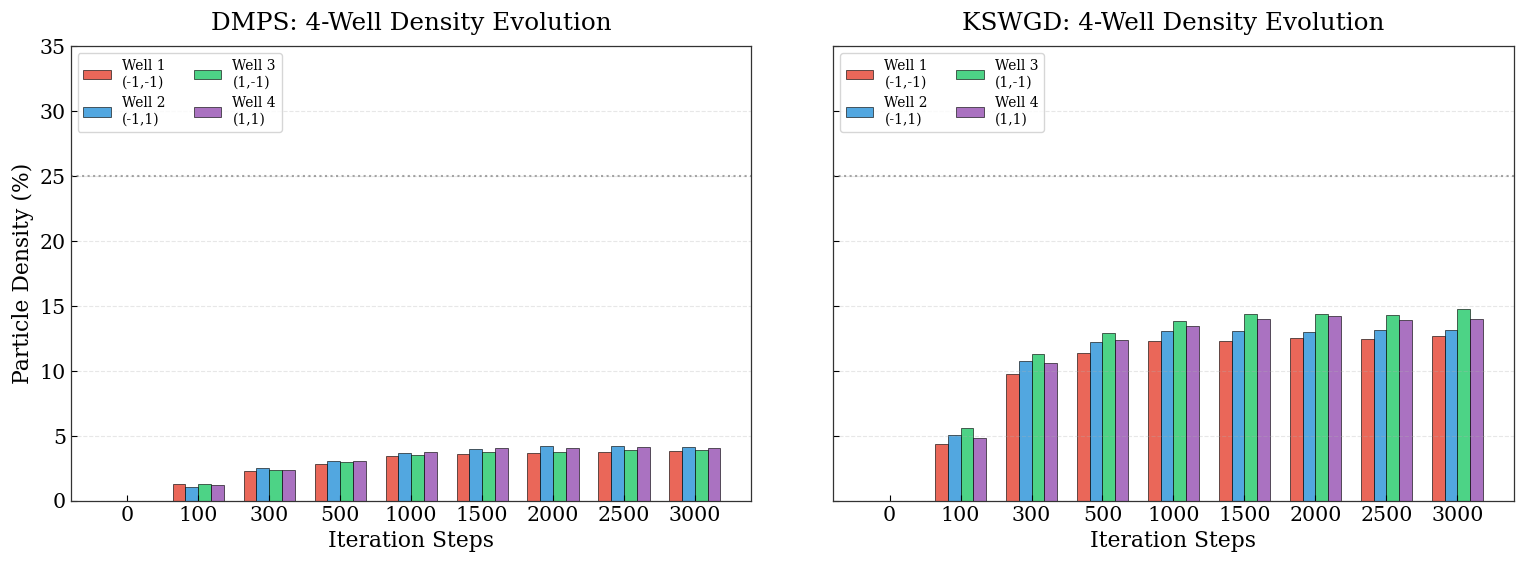

Caption: Percentage of particles in each of the four wells over iterations for DMPS and KSWGD.
Saved: figures\quadruple_well\test_2_quadruple_well_well_density_evolution.png and figures\quadruple_well\test_2_quadruple_well_well_density_evolution.pdf


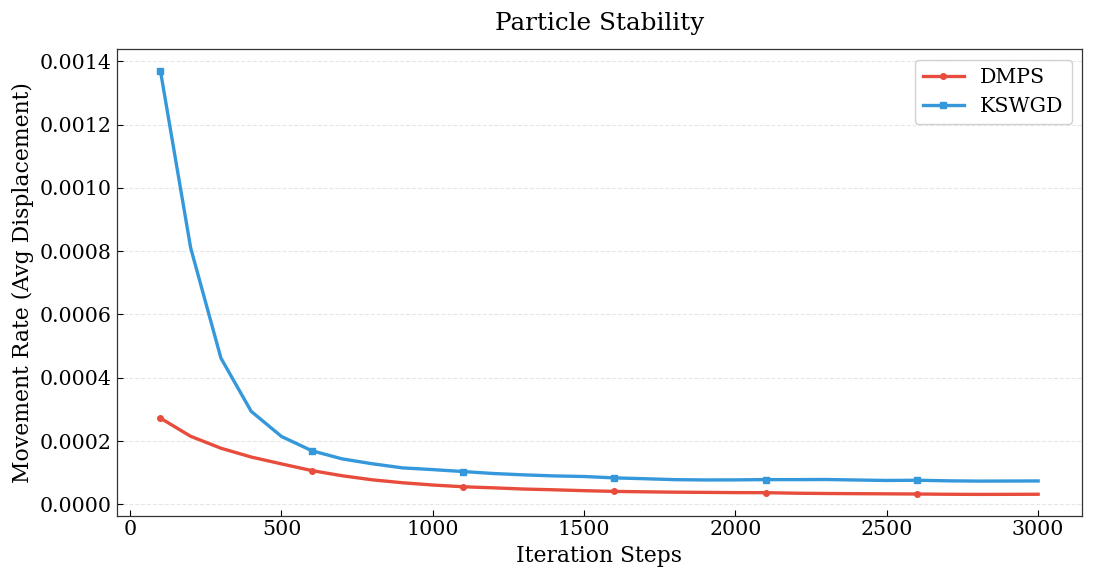

Caption: Mean particle displacement per recorded step for DMPS and KSWGD in the quadruple-well experiment.
Saved: figures\quadruple_well\test_2_quadruple_well_movement_rate.png and figures\quadruple_well\test_2_quadruple_well_movement_rate.pdf
Computing KL divergence curves...


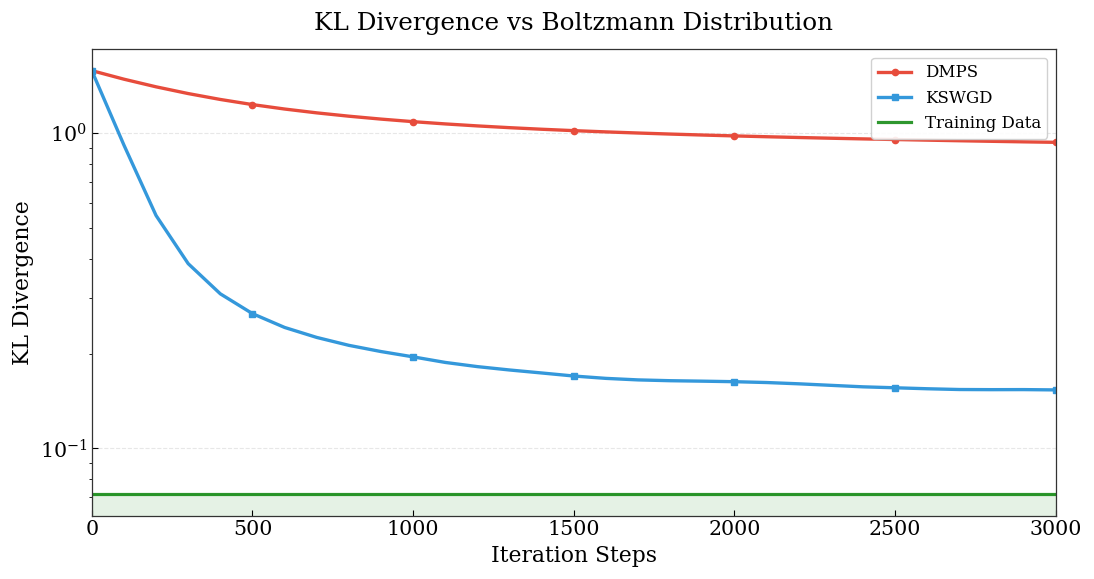

Caption: KL divergence from the true quadruple-well Boltzmann distribution over iterations for DMPS and KSWGD.
Saved: figures\quadruple_well\test_2_quadruple_well_kl_divergence.png and figures\quadruple_well\test_2_quadruple_well_kl_divergence.pdf
Training-data KL: 0.0715
DMPS: initial KL=1.5820, final KL=0.9367
KSWGD: initial KL=1.5820, final KL=0.1534


In [3]:
snapshot_view = {
    'DMPS': {step: dmps.snapshots[step] for step in SNAPSHOT_STEPS},
    'KSWGD': {step: kswgd.snapshots[step] for step in SNAPSHOT_STEPS},
}
plot_quad_pair_snapshots(
    snapshot_view, X_target=X_tar, potential=potential, bounds=cfg.bounds,
    centers=WELL_CENTERS, radius=WELL_RADIUS,
    stem='figures/quadruple_well/test_2_quadruple_well_particle_snapshots',
    caption='Quadruple-well particle positions at initialization, 1000 iterations, and 3000 iterations for DMPS and KSWGD.',
)
plot_quad_heatmaps(
    {
        'True Boltzmann Distribution': 'boltzmann',
        'KDE of Training Data': X_tar,
        'KSWGD (Step 3000)': kswgd.final,
        'DMPS (Step 3000)': dmps.final,
    },
    potential=potential, bounds=cfg.bounds,
    stem='figures/quadruple_well/test_2_quadruple_well_density_heatmaps',
    vmax_source='True Boltzmann Distribution',
    caption='Density heatmap comparison for the quadruple-well Boltzmann law, training trajectory, KSWGD final particles, and DMPS final particles.',
)
plot_quad_heatmaps(
    {
        'True Boltzmann Distribution': 'boltzmann',
        'KDE of Training Data': X_tar,
        'KSWGD (Step 3000)': kswgd.final,
    },
    potential=potential, bounds=cfg.bounds,
    stem='figures/quadruple_well/test_2_quadruple_well_density_heatmaps_1x3',
    vmax_source='True Boltzmann Distribution',
    caption='Three-panel density heatmap comparison for the quadruple-well Boltzmann law, training trajectory, and final KSWGD particles.',
)
well_density_view = {
    'DMPS': {step: dmps.snapshots[step] for step in WELL_DENSITY_STEPS},
    'KSWGD': {step: kswgd.snapshots[step] for step in WELL_DENSITY_STEPS},
}
plot_quad_well_density_evolution(
    well_density_view, centers=WELL_CENTERS, radius=WELL_RADIUS,
    stem='figures/quadruple_well/test_2_quadruple_well_well_density_evolution',
    caption='Percentage of particles in each of the four wells over iterations for DMPS and KSWGD.',
)
plot_quad_movement_rate(
    {'DMPS': dmps.metrics, 'KSWGD': kswgd.metrics},
    stem='figures/quadruple_well/test_2_quadruple_well_movement_rate',
    caption='Mean particle displacement per recorded step for DMPS and KSWGD in the quadruple-well experiment.',
)

print('Computing KL divergence curves...')
training_kl = compute_kl_divergence_kde(X_tar, potential)
kl_by_method = {}
for name, res in {'DMPS': dmps, 'KSWGD': kswgd}.items():
    values = []
    for step in KL_STEPS:
        values.append(compute_kl_divergence_kde(res.snapshots[step], potential))
    kl_by_method[name] = np.asarray(values)
plot_quad_kl_divergence(
    kl_by_method, KL_STEPS, training_kl=training_kl,
    stem='figures/quadruple_well/test_2_quadruple_well_kl_divergence',
    caption='KL divergence from the true quadruple-well Boltzmann distribution over iterations for DMPS and KSWGD.',
)
print(f'Training-data KL: {training_kl:.4f}')
for name, values in kl_by_method.items():
    print(f'{name}: initial KL={values[0]:.4f}, final KL={values[-1]:.4f}')